In [69]:
from pathlib import Path
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import interpolate
from scipy.stats import binned_statistic_2d
from scipy.interpolate import griddata

In [70]:
# Load useful parameters
df = pd.read_parquet('/Users/lucakrattinger/Documents/MA1-EPFL/TP4/code/calculated_magnitudes.parquet')

feh_list = df['feh'].tolist()
logg_list = df['logg'].tolist()
alpha_list = df['alpha'].tolist()
teff_list = df['teff'].tolist()

feh = np.array(feh_list)
logg = np.array(logg_list)
alpha = np.array(alpha_list)
teff = np.array(teff_list)

gi_listP = df['giP'].tolist()
gr_listP = df['grP'].tolist()
CaHKg_listP = df['CaHKgP'].tolist()

gi = np.array(gi_listP)
gr = np.array(gr_listP)
CaHKg = np.array(CaHKg_listP)

# Useful dataframe
df_new = pd.DataFrame({
    'metallicity': feh,
    'logg': logg,
    'Teff': teff,
    'alpha': alpha,
    'g_minus_r': gr,
    'g_minus_i': gi,
    'CaHK_minus_g' : CaHKg_listP
})

In [71]:
# Define masks

mask_rg = (
    ((teff == 4000) & (logg >= 0.0) & (logg <= 1.0))|
    ((teff == 4250) & (logg >= 0.5) & (logg <= 1.5)) |
    ((teff == 4500) & (logg >= 1.0) & (logg <= 2.0)) |
    ((teff == 4750) & (logg >= 1.5) & (logg <= 2.5)) |
    ((teff == 5000) & (logg >= 2.0) & (logg <= 3.0)) |
    ((teff == 5250) & (logg >= 2.5) & (logg <= 3.0)) |
    ((teff == 5500) & (logg == 3.0))
) #RG mask 

mask_ms = (
    (logg == 4.5)|
    (logg == 4) & (teff >= 5750) & (teff <= 6500 )|
    (logg == 5) & (teff >= 4000 ) & (teff <= 4750 )
) #MS mask

# mask data

selected_teff_rg = teff[mask_rg]
selected_logg_rg = logg[mask_rg]

selected_teff_ms = teff[mask_ms]
selected_logg_ms = logg[mask_ms]

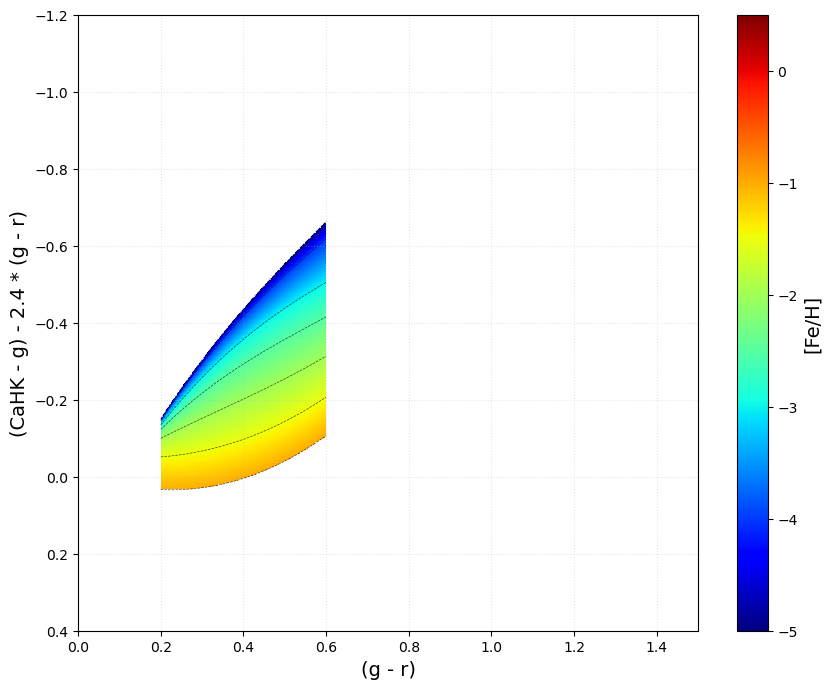

In [72]:
# Prepare containers to stock the fits
fitted_models = {} 
fitted_mets = []

met = np.arange(-5, -0.5, 0.5) 

# Store the values of the fitting curves
if 'df_new' in locals():
    for m in met:
        df_met = df_new[df_new["metallicity"] == m]
        
        if not df_met.empty:
            # Apply mask
            mask_model = (
                (df_met['logg'] == 4.5)|
                ((df_met['logg'] == 4) & (df_met['Teff'] >= 5750) & (df_met['Teff'] <= 6500 ))|
                ((df_met['logg'] == 5) & (df_met['Teff'] >= 4000) & (df_met['Teff'] <= 4750 ))
            ) 
            final_mask = mask_model & (df_met['g_minus_r'] < 1.4) & (df_met['alpha']==0.4) 
            
            x_model = df_met.loc[final_mask, 'g_minus_r']
            y_model = df_met.loc[final_mask, 'CaHK_minus_g'] - 2.4 * df_met.loc[final_mask, 'g_minus_r']

            # Check we have enough points to fit
            if len(x_model) > 3:
                try:
                    # Polynomial fit of degree 3
                    curve = np.polyfit(x_model, y_model, 3)
                    f_curve = np.poly1d(curve)
                    fitted_models[m] = f_curve
                    fitted_mets.append(m)
                except Exception:
                    pass

# Sort keys to ensure we interpolate between the correct neighbors
fitted_mets = sorted(fitted_mets)

# Create the grid
x_min_grid = 0.2  
x_max_grid = 0.6
grid_res = 500    # Resolution

x_grid = np.linspace(x_min_grid, x_max_grid, grid_res)
y_grid = np.linspace(-1.2, 0.4, grid_res)
xx, yy = np.meshgrid(x_grid, y_grid)

# Metallicity map
zz = np.full_like(xx, np.nan) 

# Calculate calibration plan
for i in range(grid_res):
    current_x = x_grid[i]
    
    # Calculate the Y-position of every metallicity line at this specific X
    # Create pairs of (y_value, metallicity)
    knots_y = []
    knots_met = []
    
    for m in fitted_mets:
        poly_func = fitted_models[m]
        y_val = poly_func(current_x)
        knots_y.append(y_val)
        knots_met.append(m)
    
    # Convert to arrays 
    knots_y = np.array(knots_y)
    knots_met = np.array(knots_met)
    
    # Sort by y value
    sort_idx = np.argsort(knots_y)
    knots_y = knots_y[sort_idx]
    knots_met = knots_met[sort_idx]
    
    # Vertical Interpolation for this column
    column_y = yy[:, i]
    
    # Interpolate [Fe/H] for this column
    col_z = np.interp(column_y, knots_y, knots_met, left=np.nan, right=np.nan)
    
    zz[:, i] = col_z

# Plot
plt.figure(figsize=(10, 8))

pcm = plt.pcolormesh(xx, yy, zz, cmap='jet', shading='auto', vmin=-5, vmax=0.5)
cbar = plt.colorbar(pcm, label='Interpolated [Fe/H]')
cbar.set_label(label='[Fe/H]', fontsize=14)

# Overlay the actual polynomial lines to verify alignment
for m in fitted_mets:
    plt.plot(x_grid, fitted_models[m](x_grid), 'k--', linewidth=0.5, alpha=0.7)

plt.gca().invert_yaxis()
#plt.title('Calibration Plane MS')
plt.xlabel('(g - r)',fontsize=14)
plt.ylabel('(CaHK - g) - 2.4 * (g - r)',fontsize=14)
plt.xlim(0, 1.5)
plt.ylim(0.4, -1.2)
plt.grid(True, linestyle=':', alpha=0.3)

plt.show()

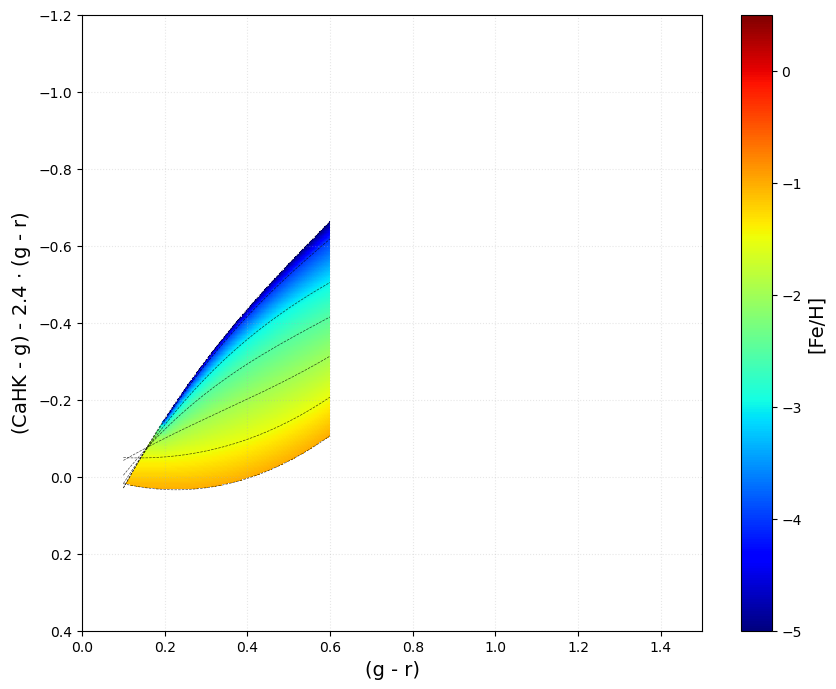

In [88]:
# Same as before but with an interpolation till g-r = 0.1
# Prepare containers to stock the fits
fitted_models = {} 
fitted_mets = []
met = np.arange(-5, -0.5, 0.5) 

# fit models 
if 'df_new' in locals():
    for m in met:
        df_met = df_new[df_new["metallicity"] == m]
        if not df_met.empty:
            # Apply mask
            mask_model = (
                (df_met['logg'] == 4.5)|
                ((df_met['logg'] == 4) & (df_met['Teff'] >= 5750) & (df_met['Teff'] <= 6500 ))|
                ((df_met['logg'] == 5) & (df_met['Teff'] >= 4000) & (df_met['Teff'] <= 4750 ))
            ) 
            final_mask = mask_model & (df_met['g_minus_r'] < 1.4) & (df_met['alpha']==0.4) 
            
            x_model = df_met.loc[final_mask, 'g_minus_r']
            y_model = df_met.loc[final_mask, 'CaHK_minus_g'] - 2.4 * df_met.loc[final_mask, 'g_minus_r']

            if len(x_model) > 3:
                try:
                    curve = np.polyfit(x_model, y_model, 3)
                    f_curve = np.poly1d(curve)
                    fitted_models[m] = f_curve
                    fitted_mets.append(m)
                except Exception:
                    pass

fitted_mets = sorted(fitted_mets)

# Grid setup
x_min_grid = 0.1  
x_max_grid = 0.6
grid_res = 500      

x_grid = np.linspace(x_min_grid, x_max_grid, grid_res)
y_grid = np.linspace(-1.2, 0.4, grid_res)
xx, yy = np.meshgrid(x_grid, y_grid)
zz = np.full_like(xx, np.nan) 

# Calibration plan
for i in range(grid_res):
    current_x = x_grid[i]
    
    # We pretend we are always at x=0.2 if we are to the left of it.
    if current_x < 0.2:
        color_eval_x = 0.2
    else:
        color_eval_x = current_x
        
    knots_y = []
    knots_met = []
    
    for m in fitted_mets:
        poly_func = fitted_models[m]
        # Calculate knots at the "clamped" position
        y_val = poly_func(color_eval_x)
        knots_y.append(y_val)
        knots_met.append(m)
    
    # Sort knots for interpolation
    knots_y = np.array(knots_y)
    knots_met = np.array(knots_met)
    sort_idx = np.argsort(knots_y)
    knots_y = knots_y[sort_idx]
    knots_met = knots_met[sort_idx]
    
    # Interpolate the column (horizontal interp)
    col_z = np.interp(yy[:, i], knots_y, knots_met, left=np.nan, right=np.nan)
    
    # Apply mask to stay in the region
    
    # Calculate y-value of all models at the real current_x
    real_y_values = [fitted_models[m](current_x) for m in fitted_mets]
    
    # Define the envelope (highest and lowest curve at this specific x)
    y_lower_bound =  fitted_models[-5](current_x)#min(real_y_values)
    y_upper_bound =  max(real_y_values)
    
    # Create a mask that is True only inside the upper and lower metallicity
    mask_inside_curves = (yy[:, i] >= y_lower_bound) & (yy[:, i] <= y_upper_bound)
    
    # Apply mask: Set everything outside the curves to NaN
    col_z[~mask_inside_curves] = np.nan
    
    zz[:, i] = col_z


plt.figure(figsize=(10, 8))

# Plot the map
pcm = plt.pcolormesh(xx, yy, zz, cmap='jet', shading='auto', vmin=-5, vmax=0.5)
cbar = plt.colorbar(pcm, label='Interpolated [Fe/H]')
cbar.set_label(label='[Fe/H]', fontsize=14)

# Overlay the dashed lines to verify the cut is correct
for m in fitted_mets:
    plt.plot(x_grid, fitted_models[m](x_grid), 'k--', linewidth=0.5, alpha=0.7)

#plt.plot(x_grid, fitted_models[-5](x_grid), 'k--', linewidth=0.8, alpha=0.5)
#plt.plot(x_grid, fitted_models[-1](x_grid), 'k--', linewidth=0.8, alpha=0.5)


plt.gca().invert_yaxis()
plt.xlabel('(g - r)', fontsize=14)
plt.ylabel(r'(CaHK - g) - 2.4 $\cdot$ (g - r)', fontsize=14)
plt.xlim(0, 1.5)
plt.ylim(0.4, -1.2)
plt.grid(True, linestyle=':', alpha=0.3)

plt.savefig('Cal-plan-MS.png', format='png', bbox_inches='tight')
plt.show()

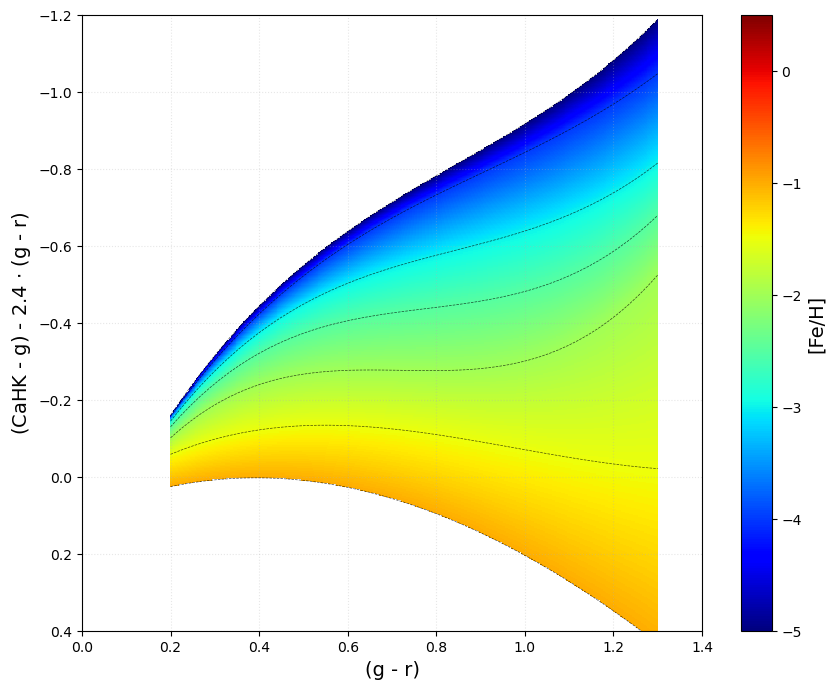

In [87]:
# Prepare containers to stock the fits
fitted_models = {} 
fitted_mets = []

# Range of metallicities
met = np.arange(-5, -0.5, 0.5) 

# Store the values of the fitting curves
if 'df_new' in locals():
    for m in met:
        df_met = df_new[df_new["metallicity"] == m]
        
        if not df_met.empty:
            # Mask data
            mask_rg = (
                ((df_met['Teff'] == 4000) & (df_met['logg'] >= 0.0) & (df_met['logg'] <= 1.0)) |
                ((df_met['Teff'] == 4250) & (df_met['logg'] >= 0.5) & (df_met['logg'] <= 1.5)) |
                ((df_met['Teff'] == 4500) & (df_met['logg'] >= 1.0) & (df_met['logg'] <= 2.0)) |
                ((df_met['Teff'] == 4750) & (df_met['logg'] >= 1.5) & (df_met['logg'] <= 2.5)) |
                ((df_met['Teff'] == 5000) & (df_met['logg'] >= 2.0) & (df_met['logg'] <= 3.0)) |
                ((df_met['Teff'] == 5250) & (df_met['logg'] >= 2.5) & (df_met['logg'] <= 3.0)) |
                ((df_met['Teff'] == 5500) & (df_met['logg'] == 3.0)) |
                ((df_met['Teff'] >= 5000) & (df_met['logg'] == 3.5))
            )

            final_mask = mask_rg & (df_met['g_minus_r'] < 1.4) & (df_met['alpha'] == 0.4) 
            
            x_model = df_met.loc[final_mask, 'g_minus_r']
            y_model = df_met.loc[final_mask, 'CaHK_minus_g'] - 2.4 * df_met.loc[final_mask, 'g_minus_r']

            # Fit points if we have enough points
            if len(x_model) > 3:
                try:
                    curve = np.polyfit(x_model, y_model, 3)
                    f_curve = np.poly1d(curve)
                    fitted_models[m] = f_curve
                    fitted_mets.append(m)
                except Exception:
                    pass

fitted_mets = sorted(fitted_mets)

# Create the grid
x_min_grid = 0.2
x_max_grid = 1.3
grid_res = 500    

x_grid = np.linspace(x_min_grid, x_max_grid, grid_res)
y_grid = np.linspace(-1.2, 0.4, grid_res)
xx, yy = np.meshgrid(x_grid, y_grid)

# Metallicity map container
zz = np.full_like(xx, np.nan) 

# -Calibration plan
for i in range(grid_res):
    current_x = x_grid[i]
    
    knots_y = []
    knots_met = []
    
    # Get y positions of RG metallicity lines at this x
    for m in fitted_mets:
        poly_func = fitted_models[m]
        y_val = poly_func(current_x)
        knots_y.append(y_val)
        knots_met.append(m)
    
    knots_y = np.array(knots_y)
    knots_met = np.array(knots_met)
    
    # Sort by y value 
    sort_idx = np.argsort(knots_y)
    knots_y = knots_y[sort_idx]
    knots_met = knots_met[sort_idx]
    
    # Vertical Interpolation
    column_y = yy[:, i]
    
    # Calculate [Fe/H] for this column
    col_z = np.interp(column_y, knots_y, knots_met, left=np.nan, right=np.nan)
    zz[:, i] = col_z


plt.figure(figsize=(10, 8))

pcm = plt.pcolormesh(xx, yy, zz, cmap='jet', shading='auto', vmin=-5, vmax=0.5)
cbar = plt.colorbar(pcm, label='Interpolated [Fe/H]')
cbar.set_label(label='[Fe/H]', fontsize=14)

for m in fitted_mets:
    x_line = np.linspace(x_min_grid, x_max_grid, 50)
    plt.plot(x_line, fitted_models[m](x_line), 'k--', linewidth=0.5, alpha=0.7)

plt.gca().invert_yaxis()
#plt.title('Calibration Plane RG')
plt.xlabel('(g - r)',fontsize=14)
plt.ylabel(r'(CaHK - g) - 2.4 $\cdot$ (g - r)',fontsize=14)

plt.xlim(0, 1.4)
plt.ylim(0.4, -1.2)
plt.grid(True, linestyle=':', alpha=0.3)

plt.savefig('Cal-plan-RG.png', format='png', bbox_inches='tight')
plt.show()

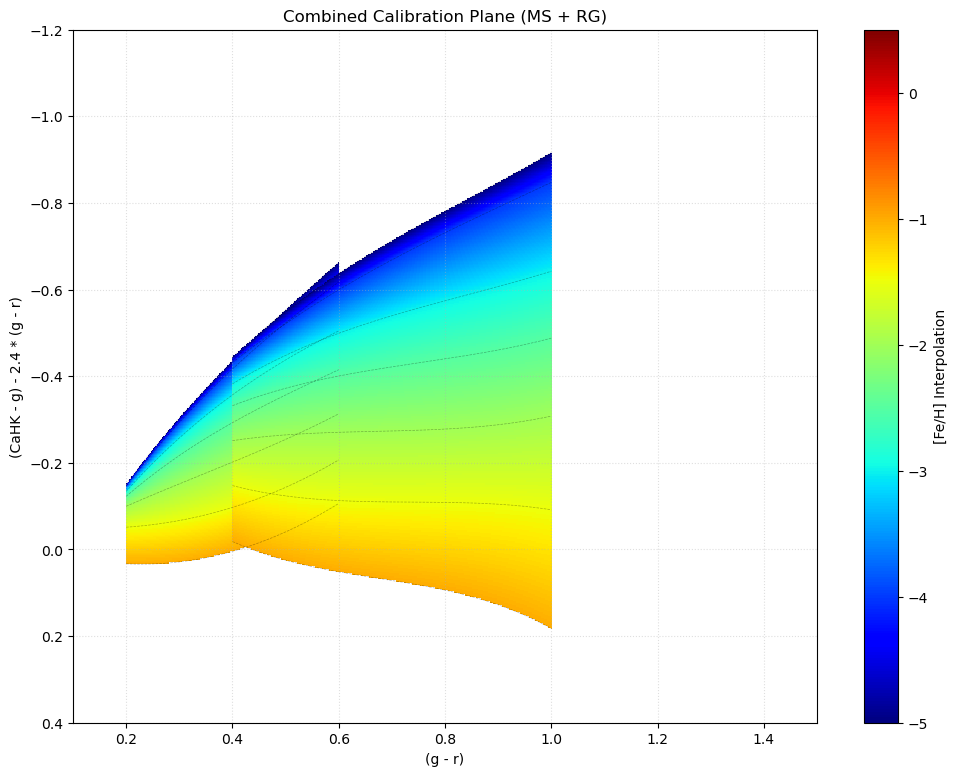

In [ ]:
# setup containers
ms_models = {}
ms_mets = []
rg_models = {}
rg_mets = []

met_range = np.arange(-5, -0.5, 0.5) 

# fitting loop
if 'df_new' in locals():
    for m in met_range:
        df_met = df_new[df_new["metallicity"] == m]
        
        if not df_met.empty:
            # MS fit
            mask_ms = (
                (df_met['logg'] == 4.5)|
                ((df_met['logg'] == 4) & (df_met['Teff'] >= 5750) & (df_met['Teff'] <= 6500 ))|
                ((df_met['logg'] == 5) & (df_met['Teff'] >= 4000) & (df_met['Teff'] <= 4750 ))
            ) 
            final_mask_ms = mask_ms & (df_met['g_minus_r'] < 1.4) & (df_met['alpha']==0.4)
            
            x_ms = df_met.loc[final_mask_ms, 'g_minus_r']
            y_ms = df_met.loc[final_mask_ms, 'CaHK_minus_g'] - 2.4 * df_met.loc[final_mask_ms, 'g_minus_r']

            if len(x_ms) > 3:
                try:
                    f_curve = np.poly1d(np.polyfit(x_ms, y_ms, 3))
                    ms_models[m] = f_curve
                    ms_mets.append(m)
                except: pass

            # RG fit
            mask_rg = (
                ((df_met['Teff'] == 4000) & (df_met['logg'] >= 0.0) & (df_met['logg'] <= 1.0)) |
                ((df_met['Teff'] == 4250) & (df_met['logg'] >= 0.5) & (df_met['logg'] <= 1.5)) |
                ((df_met['Teff'] == 4500) & (df_met['logg'] >= 1.0) & (df_met['logg'] <= 2.0)) |
                ((df_met['Teff'] == 4750) & (df_met['logg'] >= 1.5) & (df_met['logg'] <= 2.5)) |
                ((df_met['Teff'] == 5000) & (df_met['logg'] >= 2.0) & (df_met['logg'] <= 3.0)) |
                ((df_met['Teff'] == 5250) & (df_met['logg'] >= 2.5) & (df_met['logg'] <= 3.0)) |
                ((df_met['Teff'] == 5500) & (df_met['logg'] == 3.0))
            )
            final_mask_rg = mask_rg & (df_met['g_minus_r'] < 1.6) & (df_met['alpha']==0.4)

            x_rg = df_met.loc[final_mask_rg, 'g_minus_r']
            y_rg = df_met.loc[final_mask_rg, 'CaHK_minus_g'] - 2.4 * df_met.loc[final_mask_rg, 'g_minus_r']

            if len(x_rg) > 3:
                try:
                    f_curve = np.poly1d(np.polyfit(x_rg, y_rg, 3))
                    rg_models[m] = f_curve
                    rg_mets.append(m)
                except: pass

# Clean lists
ms_mets = sorted(list(set(ms_mets)))
rg_mets = sorted(list(set(rg_mets)))


# function to generate grids
def create_calibration_grid(x_min, x_max, models, available_mets):
    grid_res = 500
    x_grid = np.linspace(x_min, x_max, grid_res)
    y_grid = np.linspace(-1.2, 0.4, grid_res)
    xx, yy = np.meshgrid(x_grid, y_grid)
    zz = np.full_like(xx, np.nan)

    for i in range(grid_res):
        current_x = x_grid[i]
        knots_y, knots_met = [], []
        
        for m in available_mets:
            if m in models:
                knots_y.append(models[m](current_x))
                knots_met.append(m)
        
        if len(knots_y) > 1:
            knots_y = np.array(knots_y)
            knots_met = np.array(knots_met)
            sort_idx = np.argsort(knots_y)
            
            # Interpolate column
            zz[:, i] = np.interp(yy[:, i], knots_y[sort_idx], knots_met[sort_idx], left=np.nan, right=np.nan)
            
    return xx, yy, zz, x_grid

#  Generate two grids
# MS Grid
xx_ms, yy_ms, zz_ms, x_line_ms = create_calibration_grid(0.2, 0.6, ms_models, ms_mets)

# RG Grid
xx_rg, yy_rg, zz_rg, x_line_rg = create_calibration_grid(0.4, 1.0, rg_models, rg_mets)


plt.figure(figsize=(12, 9))

cmap = plt.get_cmap('jet')

# Plot MS Grid
pcm1 = plt.pcolormesh(xx_ms, yy_ms, zz_ms, cmap=cmap, shading='auto', vmin=-5, vmax=0.5)

# Plot RG Grid
pcm2 = plt.pcolormesh(xx_rg, yy_rg, zz_rg, cmap=cmap, shading='auto', vmin=-5, vmax=0.5)

# Overlay lines to check fit quality
for m in ms_mets:
    plt.plot(x_line_ms, ms_models[m](x_line_ms), 'k--', lw=0.5, alpha=0.3)
for m in rg_mets:
    plt.plot(x_line_rg, rg_models[m](x_line_rg), 'k--', lw=0.5, alpha=0.3)

#plt.text(0.3, 0.2, "Main Sequence", fontsize=12, fontweight='bold', color='black', alpha=0.7)
#plt.text(1.0, -0.8, "Red Giants", fontsize=12, fontweight='bold', color='black', alpha=0.7)

cbar = plt.colorbar(pcm1, label='[Fe/H] Interpolation')
cbar.set_label(label='[Fe/H]', fontsize=14)
plt.gca().invert_yaxis()
plt.xlabel('(g - r)',fontsize=14)
plt.ylabel(r'(CaHK - g) - 2.4 $\cdot$ (g - r)',fontsize=14)
plt.title('Combined Calibration Plane (MS + RG)')
plt.xlim(0.1, 1.5)
plt.ylim(0.4, -1.2)
plt.grid(True, linestyle=':', alpha=0.4)

plt.show()

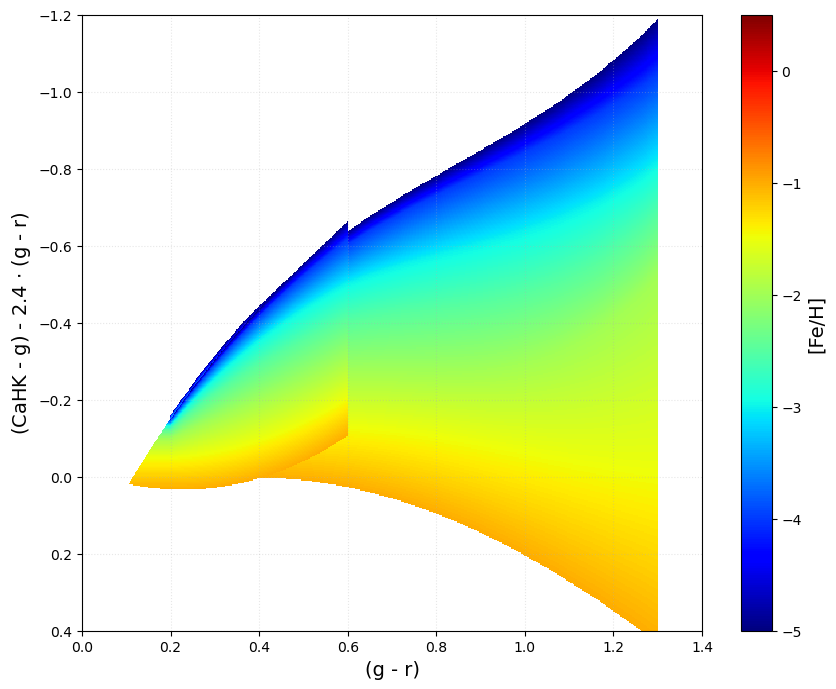

In [86]:

# Setup containers and fitting
ms_models = {}
ms_mets = []
rg_models = {}
rg_mets = []

met_range = np.arange(-5, -0.5, 0.5) 

# fitting loop
if 'df_new' in locals():
    for m in met_range:
        df_met = df_new[df_new["metallicity"] == m]
        
        if not df_met.empty:
            # MS FIT 
            mask_ms = (
                (df_met['logg'] == 4.5)|
                ((df_met['logg'] == 4) & (df_met['Teff'] >= 5750) & (df_met['Teff'] <= 6500 ))|
                ((df_met['logg'] == 5) & (df_met['Teff'] >= 4000) & (df_met['Teff'] <= 4750 ))
            ) 
            final_mask_ms = mask_ms & (df_met['g_minus_r'] < 1.4) & (df_met['alpha']==0.4)
            
            x_ms = df_met.loc[final_mask_ms, 'g_minus_r']
            y_ms = df_met.loc[final_mask_ms, 'CaHK_minus_g'] - 2.4 * df_met.loc[final_mask_ms, 'g_minus_r']

            if len(x_ms) > 3:
                try:
                    f_curve = np.poly1d(np.polyfit(x_ms, y_ms, 3))
                    ms_models[m] = f_curve
                    ms_mets.append(m)
                except: pass

            # RG FIT
            mask_rg = (
                ((df_met['Teff'] == 4000) & (df_met['logg'] >= 0.0) & (df_met['logg'] <= 1.0)) |
                ((df_met['Teff'] == 4250) & (df_met['logg'] >= 0.5) & (df_met['logg'] <= 1.5)) |
                ((df_met['Teff'] == 4500) & (df_met['logg'] >= 1.0) & (df_met['logg'] <= 2.0)) |
                ((df_met['Teff'] == 4750) & (df_met['logg'] >= 1.5) & (df_met['logg'] <= 2.5)) |
                ((df_met['Teff'] == 5000) & (df_met['logg'] >= 2.0) & (df_met['logg'] <= 3.0)) |
                ((df_met['Teff'] == 5250) & (df_met['logg'] >= 2.5) & (df_met['logg'] <= 3.0)) |
                ((df_met['Teff'] == 5500) & (df_met['logg'] == 3.0)) |
                ((df_met['Teff'] >= 5000) & (df_met['logg'] == 3.5))
            )
            final_mask_rg = mask_rg & (df_met['g_minus_r'] < 1.6) & (df_met['alpha']==0.4)

            x_rg = df_met.loc[final_mask_rg, 'g_minus_r']
            y_rg = df_met.loc[final_mask_rg, 'CaHK_minus_g'] - 2.4 * df_met.loc[final_mask_rg, 'g_minus_r']

            if len(x_rg) > 3:
                try:
                    f_curve = np.poly1d(np.polyfit(x_rg, y_rg, 3))
                    rg_models[m] = f_curve
                    rg_mets.append(m)
                except: pass

# Clean and sort lists
ms_mets = sorted(list(set(ms_mets)))
rg_mets = sorted(list(set(rg_mets)))



# Generate RG grid

# RG Setup
x_min_rg = 0.2
x_max_rg = 1.3
grid_res = 500

x_grid_rg = np.linspace(x_min_rg, x_max_rg, grid_res)
y_grid_rg = np.linspace(-1.2, 0.4, grid_res)
xx_rg, yy_rg = np.meshgrid(x_grid_rg, y_grid_rg)
zz_rg = np.full_like(xx_rg, np.nan)

# RG Calculation Loop
for i in range(grid_res):
    current_x = x_grid_rg[i]
    knots_y, knots_met = [], []
    
    for m in rg_mets:
        knots_y.append(rg_models[m](current_x))
        knots_met.append(m)
        
    knots_y = np.array(knots_y)
    knots_met = np.array(knots_met)
    
    # Sort
    sort_idx = np.argsort(knots_y)
    knots_y = knots_y[sort_idx]
    knots_met = knots_met[sort_idx]
    
    # Interpolate column
    zz_rg[:, i] = np.interp(yy_rg[:, i], knots_y, knots_met, left=np.nan, right=np.nan)


# Generate MS Grid

# MS Setup
x_min_ms = 0.1 
x_max_ms = 0.6
grid_res = 500      

x_grid_ms = np.linspace(x_min_ms, x_max_ms, grid_res)
y_grid_ms = np.linspace(-1.2, 0.4, grid_res)
xx_ms, yy_ms = np.meshgrid(x_grid_ms, y_grid_ms)
zz_ms = np.full_like(xx_ms, np.nan) 

# MS Calculation Loop
for i in range(grid_res):
    current_x = x_grid_ms[i]
    
    if current_x < 0.2:
        color_eval_x = 0.2
    else:
        color_eval_x = current_x
        
    knots_y = []
    knots_met = []
    
    for m in ms_mets:
        y_val = ms_models[m](color_eval_x)
        knots_y.append(y_val)
        knots_met.append(m)
    
    knots_y = np.array(knots_y)
    knots_met = np.array(knots_met)
    sort_idx = np.argsort(knots_y)
    knots_y = knots_y[sort_idx]
    knots_met = knots_met[sort_idx]
    
    # Interpolate (Horizontal)
    col_z = np.interp(yy_ms[:, i], knots_y, knots_met, left=np.nan, right=np.nan)
    
    real_y_values = [ms_models[m](current_x) for m in ms_mets]
    
    # Define envelope
    y_lower_bound =  fitted_models[-5](current_x)#min(real_y_values)
    y_upper_bound =  max(real_y_values)
    
    # Mask outside the physical curves
    mask_inside_curves = (yy_ms[:, i] >= y_lower_bound) & (yy_ms[:, i] <= y_upper_bound)
    col_z[~mask_inside_curves] = np.nan
    
    zz_ms[:, i] = col_z


# Plotting

plt.figure(figsize=(10, 8))

# Plot RG
pcm_rg = plt.pcolormesh(xx_rg, yy_rg, zz_rg, cmap='jet', shading='auto', vmin=-5, vmax=0.5)

# Plot MS
pcm_ms = plt.pcolormesh(xx_ms, yy_ms, zz_ms, cmap='jet', shading='auto', vmin=-5, vmax=0.5)

cbar = plt.colorbar(pcm_rg, label='Interpolated [Fe/H]')
cbar.set_label(label='[Fe/H]', fontsize=14)

# Overlay MS lines (Full range to show fit quality)
#for m in ms_mets:
   #plt.plot(x_grid_ms, ms_models[m](x_grid_ms), 'k--', linewidth=0.5, alpha=0.7)

# Overlay RG lines
#for m in rg_mets:
    #plt.plot(x_grid_rg, rg_models[m](x_grid_rg), 'k--', linewidth=0.5, alpha=0.7)

plt.gca().invert_yaxis()
plt.xlabel('(g - r)', fontsize=14)
plt.ylabel(r'(CaHK - g) - 2.4 $\cdot$ (g - r)', fontsize=14)

plt.xlim(0, 1.4)
plt.ylim(0.4, -1.2)
plt.grid(True, linestyle=':', alpha=0.3)

plt.savefig('bothplan.png', format='png', bbox_inches='tight')
plt.show()

In [55]:
# Save all relevant arrays into one compressed file
np.savez('calibration_grids.npz', 
         xx_ms=xx_ms, yy_ms=yy_ms, zz_ms=zz_ms, 
         xx_rg=xx_rg, yy_rg=yy_rg, zz_rg=zz_rg)

print("Grids saved to calibration_grids.npz")

Grids saved to calibration_grids.npz
